First 5 rows of the dataset:
                   PassengerId\tSurvived\tPclass\tName\tSex\tAge\tSibSp\tParch\tTicket\tFare\tCabin\tEmbarked
1\t0\t3\tBraund      Mr. Owen Harris\tmale\t22\t1\t0\tA/5 21171\t7...                                        
2\t1\t1\tCumings     Mrs. John Bradley (Florence Briggs Thayer)\tf...                                        
3\t1\t3\tHeikkinen   Miss. Laina\tfemale\t26\t0\t0\tSTON/O2. 31012...                                        
4\t1\t1\tFutrelle    Mrs. Jacques Heath (Lily May Peel)\tfemale\t3...                                        
5\t0\t3\tAllen       Mr. William Henry\tmale\t35\t0\t0\t373450\t8....                                        

Dataset shape: (156, 1)

Null values in each column:
PassengerId\tSurvived\tPclass\tName\tSex\tAge\tSibSp\tParch\tTicket\tFare\tCabin\tEmbarked    0
dtype: int64


C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


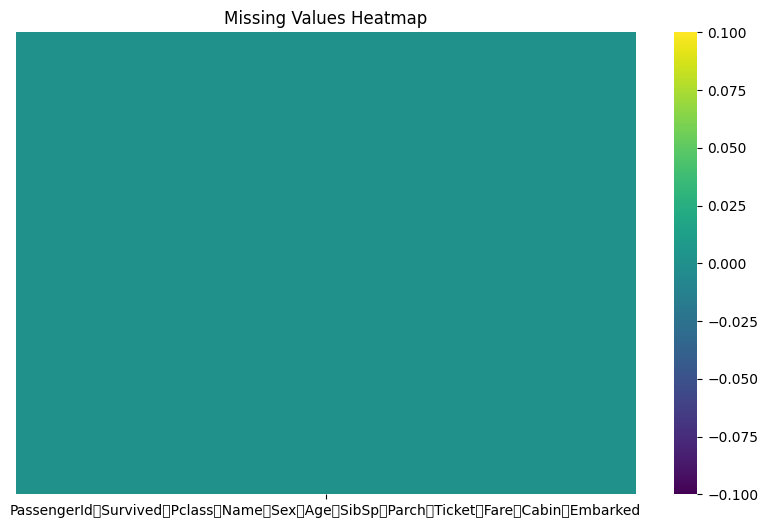


Original dataset columns:
['PassengerId\tSurvived\tPclass\tName\tSex\tAge\tSibSp\tParch\tTicket\tFare\tCabin\tEmbarked']

'deck' column not found in dataset

Shape before dropping null values: (156, 1)
Shape after dropping null values: (156, 1)


C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\vihaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


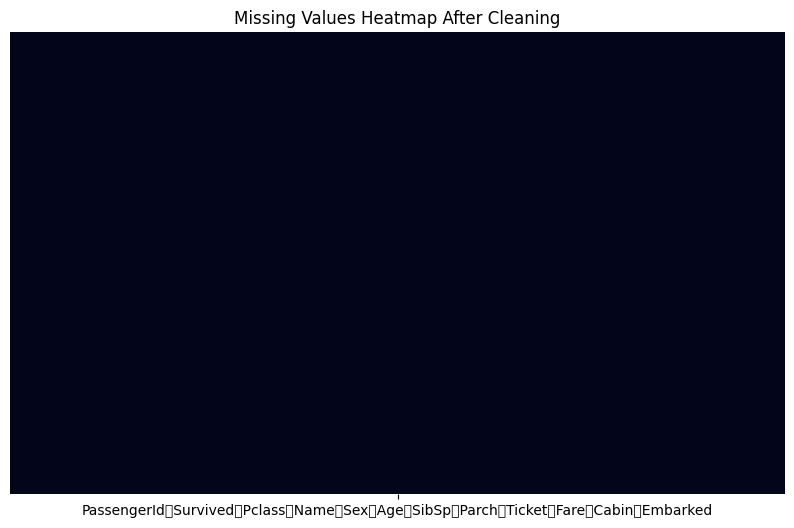


Null values after cleaning:
PassengerId\tSurvived\tPclass\tName\tSex\tAge\tSibSp\tParch\tTicket\tFare\tCabin\tEmbarked    0
dtype: int64

Converting categorical variables to dummy variables...
'sex' column not found
'embarked' column not found
'pclass' column not found

No categorical columns found for dummy encoding

Basic statistics of the processed dataset:
       PassengerId\tSurvived\tPclass\tName\tSex\tAge\tSibSp\tParch\tTicket\tFare\tCabin\tEmbarked
count                                                 156                                        
unique                                                156                                        
top      Mr. Owen Harris\tmale\t22\t1\t0\tA/5 21171\t7...                                        
freq                                                    1                                        


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic = pd.read_csv("titanic.csv")  # Removed raw string prefix, normalized filename
print("First 5 rows of the dataset:")
print(titanic.head())

# Check the shape of the dataset
print(f"\nDataset shape: {titanic.shape}")

# Check for null values
print("\nNull values in each column:")
print(titanic.isnull().sum())

# Visualize null values using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cmap="viridis", cbar=True, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

# Since the highest null values are found in "deck" column, dropping it
print("\nOriginal dataset columns:")
print(titanic.columns.tolist())

# Dropping the deck column (if it exists)
if 'deck' in titanic.columns:
    titanic.drop("deck", axis=1, inplace=True)
    print("\nDataset after dropping 'deck' column:")
    print(titanic.head())
else:
    print("\n'deck' column not found in dataset")

# Remove rows with any null values
print(f"\nShape before dropping null values: {titanic.shape}")
titanic.dropna(inplace=True)
print(f"Shape after dropping null values: {titanic.shape}")

# Visualize null values after cleaning
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap After Cleaning")
plt.show()

# Verify no null values remain
print("\nNull values after cleaning:")
print(titanic.isnull().sum())

# Convert categorical variables to dummy variables
print("\nConverting categorical variables to dummy variables...")

# For 'sex' column
if 'sex' in titanic.columns:
    print("\nOriginal sex column:")
    print(titanic["sex"].value_counts())
    
    sex_dummies = pd.get_dummies(titanic["sex"], drop_first=True)
    print("\nSex dummy variables:")
    print(sex_dummies.head())
else:
    print("'sex' column not found")

# For 'embarked' column
if 'embarked' in titanic.columns:
    print("\nOriginal embarked column:")
    print(titanic["embarked"].value_counts())
    
    embarked_dummies = pd.get_dummies(titanic["embarked"], drop_first=True)
    print("\nEmbarked dummy variables:")
    print(embarked_dummies.head())
else:
    print("'embarked' column not found")

# For 'pclass' column
if 'pclass' in titanic.columns:
    print("\nOriginal pclass column:")
    print(titanic["pclass"].value_counts())
    
    pclass_dummies = pd.get_dummies(titanic["pclass"], drop_first=True)
    print("\nPclass dummy variables:")
    print(pclass_dummies.head())
else:
    print("'pclass' column not found")

# Concatenate original dataset with dummy variables
dummy_columns = []
if 'sex' in titanic.columns:
    dummy_columns.append(sex_dummies)
if 'embarked' in titanic.columns:
    dummy_columns.append(embarked_dummies)
if 'pclass' in titanic.columns:
    dummy_columns.append(pclass_dummies)

if dummy_columns:
    titanic_processed = pd.concat([titanic] + dummy_columns, axis=1)
    
    # Remove original categorical columns that were converted to dummies
    columns_to_drop = ['sex', 'embarked', 'pclass']
    columns_to_drop = [col for col in columns_to_drop if col in titanic_processed.columns]
    titanic_processed.drop(columns_to_drop, axis=1, inplace=True)
    
    print("\nFinal processed dataset:")
    print(titanic_processed.head())
    print(f"\nFinal dataset shape: {titanic_processed.shape}")
    print(f"\nFinal dataset columns: {titanic_processed.columns.tolist()}")
else:
    print("\nNo categorical columns found for dummy encoding")
    titanic_processed = titanic

# Display basic statistics
print("\nBasic statistics of the processed dataset:")
print(titanic_processed.describe())